In [ ]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import matplotlib.patches as mpatches

In [22]:
df=pd.read_csv("IMDB Dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [23]:
x=df['review']
y=df['sentiment']
le=LabelEncoder()
y=le.fit_transform(y)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4,random_state=0)

In [24]:
tfid=TfidfVectorizer(max_features=5000)
x_train=tfid.fit_transform(x_train)
x_test=tfid.transform(x_test)
np.unique(x_train.data)

array([0.00316629, 0.00339801, 0.00347227, ..., 0.87313296, 0.90977381,
       0.91226527], shape=(3459385,))

In [ ]:
sample_size = 2000
x_sample = x_train[:sample_size]
y_sample = y_train[:sample_size]
x_sample = x_sample.toarray()
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_sample)
colors = ['red' if label == 0 else 'green' for label in y_sample]
plt.figure(figsize=(10,7))
plt.scatter(x_pca[:,0], x_pca[:,1], c=colors, alpha=0.6)
red_patch = mpatches.Patch(color='red', label='Negative')
green_patch = mpatches.Patch(color='green', label='Positive')
plt.legend(handles=[red_patch, green_patch])
plt.title("PCA Visualization of IMDB Sentiment Data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [27]:
model=LinearSVC()
param={'C': [0.01, 0.1, 1, 10]}
optimal_params=GridSearchCV(model,param,cv=3,scoring='f1')
optimal_params.fit(x_train,y_train)

GridSearchCV(cv=3, estimator=LinearSVC(), param_grid={'C': [0.01, 0.1, 1, 10]},
             scoring='f1')

In [ ]:
optimal_params.best_estimator_

LinearSVC(C=0.01)

In [26]:
optimal_model=LinearSVC(C=0.01)
optimal_model.fit(x_train,y_train)


LinearSVC(C=0.01)

In [31]:
y_pred=optimal_model.predict(x_test)

In [32]:
f1_score(y_test,y_pred)

0.8600039269585706

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85     10068
           1       0.84      0.88      0.86      9932

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



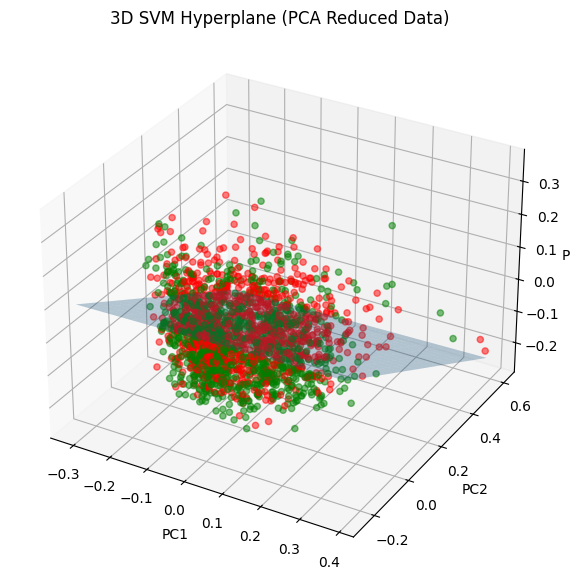

In [35]:
sample_size = 2000
X_sample = x_train[:sample_size].toarray()
y_sample = y_train[:sample_size]
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X_sample)
model_3d = SVC(kernel='linear')
model_3d.fit(X_3d, y_sample)
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
colors = ['red' if label == 0 else 'green' for label in y_sample]
ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2], c=colors, alpha=0.5)
w = model_3d.coef_[0]
b = model_3d.intercept_[0]
xx, yy = np.meshgrid(
    np.linspace(X_3d[:,0].min(), X_3d[:,0].max(), 20),
    np.linspace(X_3d[:,1].min(), X_3d[:,1].max(), 20)
)
zz = (-w[0]*xx - w[1]*yy - b) / w[2]
ax.plot_surface(xx, yy, zz, alpha=0.3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D SVM Hyperplane (PCA Reduced Data)")
plt.show()
